# PS-S06E02: LightGBM

This notebook tackles the [**Playground Series – Season 6, Episode 2: Predicting Heart Disease**](https://www.kaggle.com/competitions/playground-series-s6e2), a competition focused on predicting if a patient has heart disease, based on features describing the patient's demographics and selected health metrics.

The task is **binary classification**: predict whether heart disease is **Present** or **Absent**. The leaderboard metric is **ROC AUC**.

## Introduction

**LightGBM** distinguishes itself with a "leaf-wise" (best-first) tree growth strategy, contrasting with the traditional "level-wise" (depth-wise) approach used by XGBoost. This allows it to converge faster and often capture more complex, non-linear dependencies in physiological data. It handles missing values internally and is highly optimized for memory efficiency and training speed. While LightGBM has native support for categorical features, we will utilize our refined feature engineering pipeline to ensure robust inputs.

The notebook is one of a number of notebooks that explore various models to address this challenge, with the ultimate goal of ensembling these diverse learners. The EDA for this dataset was performed in this notebook: [**PS-S06E02: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e02-eda).

## Install Needed Packages

In [1]:
%pip install --no-binary lightgbm --config-settings=cmake.define.USE_CUDA=ON lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.exceptions import TrialPruned
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e02_feature_engineering import FeatureFactory
from ps_s06e02_model_visualizer import ModelVisualizer
from ps_s06e02_experiment_setup import ExperimentSetup

# Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Heart Disease'

# Show GPU be utilized in training
USE_GPU = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_dataset("training")

TRAINING DATASET

   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1          3.600            2   
1     171                0          0.000            1   
2     151                0          0.000            1   
3     150                0          1.000            2   
4     125                1          3.800            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3    

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset("test")

TEST DATASET

       id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0  630000   58    1                3  120          288             0   
1  630001   55    0                2  120          209             0   
2  630002   54    1                4  120          268             0   
3  630003   44    0                3  112          177             0   
4  630004   43    1                1  138          267             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            2     145                1          0.800            2   
1            0     172                0          0.000            1   
2            0     150                1          0.000            2   
3            0     168                0          0.900            1   
4            0     163                0          1.800            2   

   Number of vessels fluro  Thallium  
0                        3         3  
1                        0         3  
2        

## Feature Engineering

In [6]:
# Define which strategies to use for the LightGBM model here:
fe_strategies = [
    'drop_id',
    'cast_categoricals',
    'numeric_transforms',
]

In [7]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET].map({"Absence": 0, "Presence": 1}).astype("int8")

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 14
New Feature Count: 17
   Age Sex Chest pain type   BP  Cholesterol FBS over 120 EKG results  Max HR  \
0   58   1               4  152          239            0           0     158   
1   52   1               1  125          325            0           2     171   
2   56   0               2  160          188            0           2     151   
3   44   0               3  134          229            0           2     150   
4   58   1               4  140          234            0           2     125   

  Exercise angina  ST depression Slope of ST Number of vessels fluro Thallium  \
0               1          3.600           2                       2        7   
1               0          0.000           1                       0        3   
2               0          0.000           1                       0        3   
3               0          1.000           2                       0        3   
4               1       

## Optuna Tuning

In [8]:
print("Precomputing fold-wise FE for Optuna (once)...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    X_train_fold = training_df.iloc[train_idx].copy()
    X_val_fold   = training_df.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold   = y.iloc[val_idx].copy()

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    cat_cols = [c for c in cat_cols if c in X_val_trans.columns]

    fold_cache.append((X_train_trans, y_train_fold, X_val_trans, y_val_fold, cat_cols, val_idx))

print("Cached folds:", len(fold_cache))


Precomputing fold-wise FE for Optuna (once)...
Cached folds: 5


In [9]:
n_jobs = 6

def objective(trial):
    params = {
        'n_estimators': 1200,
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08, log=True),
    
        'num_leaves': trial.suggest_int('num_leaves', 16, 96, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200, log=True),

        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 3),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
    
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True),

        'feature_pre_filter': False,
        'force_col_wise': True,

        'random_state': seed,
        # 'device_type': 'gpu' if USE_GPU else 'cpu',
        'device_type': 'cpu',  # Forcing for Optuna training
        'n_jobs': n_jobs,
        'verbosity': -1,
    }

    # Set additional parameters if on GPU
    if params['device_type'] == 'gpu':
        params['gpu_platform_id'] =  0
        params['gpu_device_id'] = 0

    oof = np.zeros(len(y), dtype=float)

    for X_train_trans, y_train_fold, X_val_trans, y_val_fold, cat_cols, val_idx in fold_cache:
        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            categorical_feature=cat_cols,
            callbacks=[
                lgb.early_stopping(25, verbose=False)
            ]
        )
    
        oof[val_idx] = model.predict_proba(X_val_trans, num_iteration=model.best_iteration_)[:,1]

        del model
        gc.collect()
        
    return roc_auc_score(y, oof)

In [10]:
if PERFORM_OPTUNA_TUNING:
    print('Starting LightGBM Optuna Optimization...')
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1
    )
    
    study_lgbm = optuna.create_study(
        direction='maximize',
        study_name='lgbm_predicting_heart_disease_optuna', 
        pruner=pruner
    )
    
    study_lgbm.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print('\nBest Trial:')
    print(f'  AUC: {study_lgbm.best_value:.5f}')
    print('  Params: ', study_lgbm.best_params)
    
    lgbm_best_params = study_lgbm.best_params
else:
    lgbm_best_params = {
        'learning_rate': 0.06378021686974122,
        'num_leaves': 57,
        'max_depth': 3,
        'min_child_samples': 23,
        'subsample': 0.9831105561880911,
        'subsample_freq': 3,
        'colsample_bytree': 0.8109128191976377,
        'reg_alpha': 0.2658637205511853,
        'reg_lambda': 0.013466408926639651
    }
    

[I 2026-02-11 16:56:32,396] A new study created in memory with name: lgbm_predicting_heart_disease_optuna


Starting LightGBM Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-11 16:57:53,038] Trial 0 finished with value: 0.9552127174203113 and parameters: {'learning_rate': 0.05226346796860612, 'num_leaves': 79, 'max_depth': 6, 'min_child_samples': 39, 'subsample': 0.8734800532760891, 'subsample_freq': 1, 'colsample_bytree': 0.8611934030760141, 'reg_alpha': 0.2952834240272492, 'reg_lambda': 0.05280923209086943}. Best is trial 0 with value: 0.9552127174203113.
[I 2026-02-11 17:06:47,891] Trial 1 finished with value: 0.9552919608924516 and parameters: {'learning_rate': 0.025882682418987724, 'num_leaves': 28, 'max_depth': 5, 'min_child_samples': 54, 'subsample': 0.9408237389310936, 'subsample_freq': 2, 'colsample_bytree': 0.929090878006057, 'reg_alpha': 0.047032931212083955, 'reg_lambda': 0.0069803252263355734}. Best is trial 1 with value: 0.9552919608924516.
[I 2026-02-11 17:13:20,926] Trial 2 finished with value: 0.9551562736549961 and parameters: {'learning_rate': 0.034338358232052515, 'num_leaves': 69, 'max_depth': 8, 'min_child_samples': 58, 'su

## Model Training

In [11]:
# Build LGB parameters from best_params
lgb_tuned_params = {
    **lgbm_best_params,
    'n_estimators': 20000,
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_jobs': n_jobs,
    'random_state': seed,
    'device_type': 'gpu' if USE_GPU else 'cpu',
    'verbosity': -1,
}

# Set additional parameters if on GPU
if lgb_tuned_params['device_type'] == 'gpu':
    lgb_tuned_params['gpu_platform_id'] =  0
    lgb_tuned_params['gpu_device_id'] = 0

print('Final LightGBM CV Training with OOF / Test probabilities')
print('======================================================')
print('Parameters used for training:')
print(lgb_tuned_params)
print(' ')

# Initialize Standard K-Fold
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_probs = np.zeros(len(y), dtype=float)
test_probs = np.zeros(len(test_df), dtype=float)

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    print(f'\nStarting processing of fold {fold+1}')

    X_train_fold = training_df.iloc[train_idx]
    X_val_fold = training_df.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans = fe.transform(X_val_fold)
    X_test_trans = fe.transform(test_df)
    
    cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    cat_cols = [c for c in cat_cols if c in X_val_trans.columns]

    model = lgb.LGBMClassifier(**lgb_tuned_params)
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(200, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )
    
    # Store history
    eval_results.append(model.evals_result_)
    models.append(model)

    val_probs = model.predict_proba(X_val_trans, num_iteration=model.best_iteration_)[:,1]
    oof_probs[val_idx] = val_probs
    
    # Score this fold
    fold_auc = roc_auc_score(y_val_fold, val_probs)
    print(f'Fold {fold+1} AUC: {fold_auc:.5f} (best_iteration={model.best_iteration_})')
    
    batch_test_probs = model.predict_proba(X_test_trans, num_iteration=model.best_iteration_)[:,1]
    test_probs += batch_test_probs / skf.n_splits

    del model
    gc.collect()
    
# Final Metric Calculation
overall_auc = roc_auc_score(y, oof_probs)
print(f'\nOverall CV AUC: {overall_auc:.5f}')

Final LightGBM CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.06378021686974122, 'num_leaves': 57, 'max_depth': 3, 'min_child_samples': 23, 'subsample': 0.9831105561880911, 'subsample_freq': 3, 'colsample_bytree': 0.8109128191976377, 'reg_alpha': 0.2658637205511853, 'reg_lambda': 0.013466408926639651, 'n_estimators': 20000, 'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt', 'n_jobs': 6, 'random_state': 10301, 'device_type': 'gpu', 'verbosity': -1, 'gpu_platform_id': 0, 'gpu_device_id': 0}
 

Starting processing of fold 1
[200]	training's auc: 0.95435	valid_1's auc: 0.954981
[400]	training's auc: 0.955173	valid_1's auc: 0.955652
[600]	training's auc: 0.955665	valid_1's auc: 0.956004
[800]	training's auc: 0.955927	valid_1's auc: 0.956106
[1000]	training's auc: 0.956106	valid_1's auc: 0.956159
[1200]	training's auc: 0.95625	valid_1's auc: 0.956191
[1400]	training's auc: 0.95638	valid_1's auc: 0.95619
Fold 1 AUC: 0.95620 (best_iter

## Visualize the Quality of Training

It is standard practice to visualize Learning Curves (to spot overfitting/underfitting) and the ROC Curve (to check classification performance).

### Learning Curves (Train vs. Validation AUC)

**Definition**  
This graph plots the model's performance (AUC) on the y-axis against the number of boosting rounds (iterations) on the x-axis. It displays two lines:
*   **Blue (Train):** How well the model learned the data it has already seen.
*   **Red (Validation):** How well the model generalizes to new data it hasn't seen.

**Interpretation**  
This graph is fairly easy to interpret, and is a powerful indicator of how the model is likely to perform on new data.
*   **Ideal:** Both lines go up steeply and plateau. The Blue line is slightly higher than the Red line, but the gap is stable.
*   **Overfitting:** The Blue line keeps going up (approaching 1.0), but the Red line flattens out early or starts dropping. The "gap" between them widens significantly.
*   **Underfitting:** Both lines flatten out very early at a low score. The model is too simple to learn the patterns.

**Actions for Overfitting**  
If the Training score is 0.95 but the validation score is 0.72, the  are overfitting.
1.  **Restrict Depth:** Reduce `max_depth` (e.g., from 6 to 3 or 4). This forces the model to learn simpler, more general rules.
2.  **Add Randomness:** Lower `subsample` and `colsample_bytree` (e.g., to 0.6). This prevents the model from relying too heavily on specific rows or features.
3.  **Increase Regularization:** Increase `reg_alpha` (L1) or `reg_lambda` (L2). This penalizes the model for becoming too complex.
4.  **Increase `min_child_weight`:** This prevents the tree from creating leaves that only apply to a tiny handful of patients (noise).

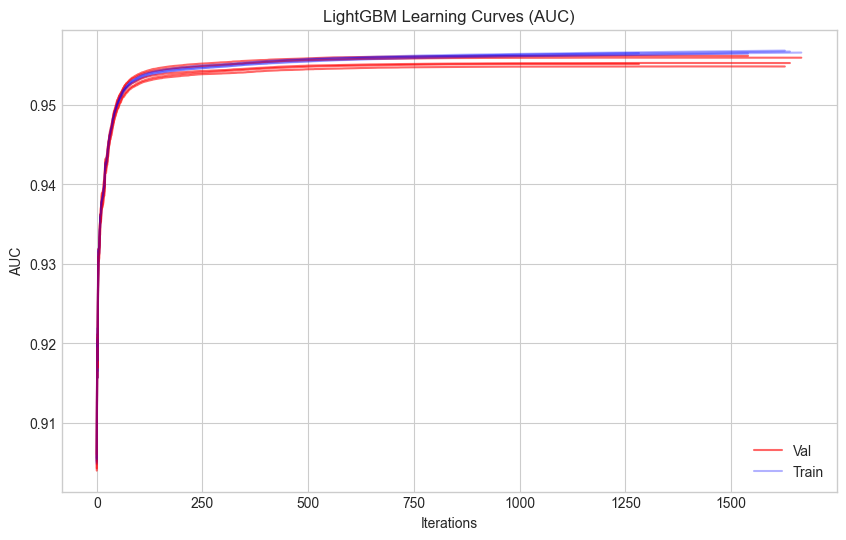

In [12]:
mviz = ModelVisualizer(model_name='LightGBM')

mviz.plot_learning_curves(eval_results, metric='auc')

### Feature Importance (Gain)

This chart ranks features by how much they improved the model's accuracy (reduced the loss function) whenever they were used in a split.

**Interpretation**  
*   **High Gain:** These are the "Signal" features. The model relies on them heavily.
*   **Low/Zero Gain:** These features were rarely useful. The model mostly ignored them.

**What if engineered features aren't at the top?**  
*   **Don't Panic:** It's okay if raw features like Glucose or BMI are still top. They are strong predictors!
*   **Check Correlations:** If BMI is #1 and your engineered BMI\_Ratio is #50, they might be highly correlated, and the model just chose the simpler one. This is fine.
*   **Re-evaluate:** If an engineered feature is at the very bottom (0 importance), it failed. The hypothesis behind it (e.g., "Age \* Height") likely has no biological relevance.

**What to do with Low Performing Features**  
*   **Zero Importance:** **Drop them.** They add computational cost and noise without adding value.
*   **Low Importance:**  
    *   **Try Dropping:** Sometimes removing "noise" features helps the model focus on the signal (increases score).
  
    *   **Combine Them:** If SkinThickness is weak on its own, try creating an interaction like Insulin / SkinThickness. Sometimes two weak features make one strong feature.

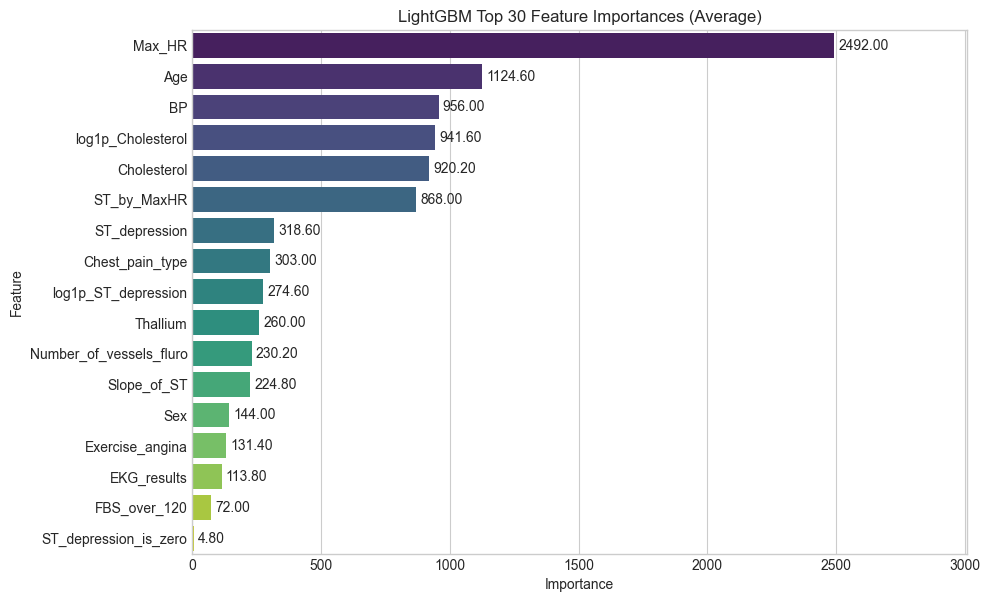

In [13]:
mviz.plot_feature_importance(models, show_values=True)

<Figure size 800x600 with 0 Axes>

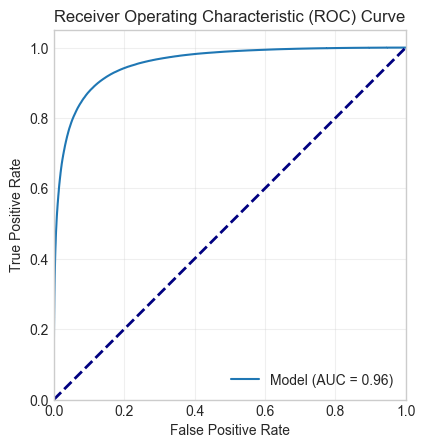

In [14]:
# ROC on OOF
mviz.plot_roc_curve(y_true=y, y_score=oof_probs)

Normalized confusion matrix


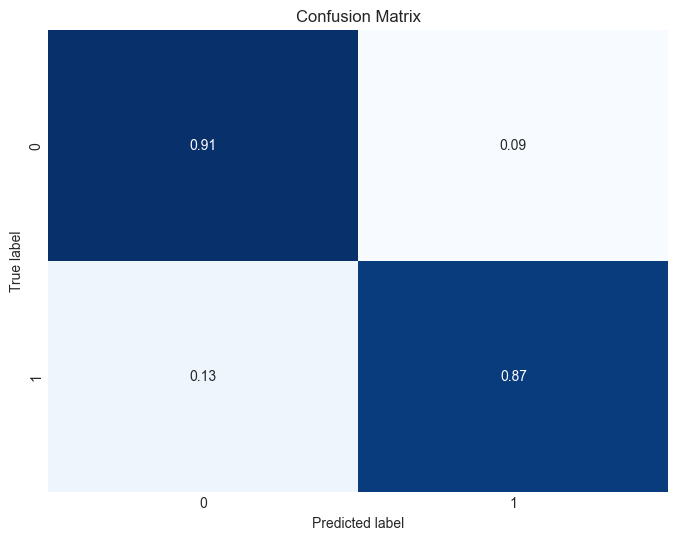

In [15]:
# Confusion matrix (threshold 0.5, adjust if needed)
y_hat = (oof_probs >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=y_hat, classes=[0, 1], normalize=True)

## Prepare Submission

In [16]:
submission_df = helper.read_dataset("submission")
submission_df[TARGET] = test_probs

print('SUBMISSION')
print('==========')

print(submission_df.head(10))

SUBMISSION
       id  Heart Disease
0  630000          0.948
1  630001          0.009
2  630002          0.988
3  630003          0.005
4  630004          0.207
5  630005          0.981
6  630006          0.004
7  630007          0.610
8  630008          0.992
9  630009          0.013


In [17]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

The OOF and test probabilities are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the probabilities of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [18]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF probabilities and Test probabilities for blending/stacking
oof_df = pd.DataFrame({
    'id': training_df['id'].values,
    'prob_lgb': oof_probs,
    'target': y.values
})
oof_df.to_csv(f'{output_dir}/lgb_oof_probs.csv', index=False)

test_prob_df = pd.DataFrame({
    'id': test_df['id'].values,
    'prob_lgb': test_probs
})
test_prob_df.to_csv(f'{output_dir}/lgb_test_probs.csv', index=False)

print(f'Saved for Blending: {output_dir}/lgb_oof_probs.csv, {output_dir}/lgb_test_probs.csv')

Saved for Blending: predictions/lgb_oof_probs.csv, predictions/lgb_test_probs.csv
